Credit scoring on dataset Give me some credit\
The goal of this project is to predict wheather a borrower will experience serious financial delinquecy within the next two years
This is a binary classification problem:

- '0' — no serious delinquency
- '1' — serious delinquency within two years

The project focuses on identifying high-risk borrowers using historical financial and credit information.

In [1259]:
#импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay




In [1260]:
train=pd.read_csv("../data/cs-training.csv")
train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [1261]:
#lets drop first column, because it don't have meaning for us
train=train.drop(columns=['Unnamed: 0'])
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [1262]:
train.shape

(150000, 11)

our dataset has 150000 samples for training and 11 columns with information

In [1263]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

some columns have type int64 , some of them float64, dataset don't have categorical columns

In [1264]:
train.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

columns MonthlyIncome and NumberOfDependents have NaN data

In [1265]:
missing= pd.DataFrame({
    "missing_count":train.isnull().sum(),
    "missing_percent": train.isnull().mean() * 100

})

missing[missing["missing_count"]>0].sort_values("missing_percent",ascending=False)

,missing_count,missing_percent
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000


we have 19% data in a column MonthlyIncome , when we will do a distribution we will see , what will be the best decision to fill that null data with median or mean

In [1266]:
duplicated = pd.DataFrame({
    "duplicated_count":[train.duplicated().sum()],
    "duplicated_percent": [train.duplicated().mean() * 100]

})

duplicated[duplicated["duplicated_count"]>0].sort_values("duplicated_percent",ascending=False)



,duplicated_count,duplicated_percent
0,609,0.406


4% of duplicated data

In [1267]:
train['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

our target variable has two classes 0 and 1. Dataset imbalanced , 1 class has just 7 % of all samples to train

In [1268]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


our dataset has outliers
Shoud see distribution of this columns: RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents

In [1269]:
train[train['age']==0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


very strange data with age = 0, maybe it inputed incorrectly

In [1270]:
train['NumberOfTimes90DaysLate'].value_counts().sort_index().tail(10)

NumberOfTimes90DaysLate
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64

In [1271]:
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]
train[train['NumberOfTimes90DaysLate'].isin([96,98])][late_cols].value_counts()

NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate
98                                    98                                    98                         264
96                                    96                                    96                           5
Name: count, dtype: int64

Delinquency count anomalies
The values 96 and 98 appear in all three features

In [1272]:
(train['RevolvingUtilizationOfUnsecuredLines']>1).sum()

np.int64(3321)

In [1273]:
(train['RevolvingUtilizationOfUnsecuredLines']>1).mean() * 100

np.float64(2.214)

just 2 % of data have RevolvingUtilizationOfUnsecuredLines>1

In [1274]:
train['DebtRatio'].quantile([0.50,0.75,0.90,0.95,0.99,0.999,1.0])

0.500         0.366508
0.750         0.868254
0.900      1267.000000
0.950      2449.000000
0.990      4979.040000
0.999     10613.074000
1.000    329664.000000
Name: DebtRatio, dtype: float64

between 75% and 90% quantile big difference, maybe it is not accident

In [1275]:
train['DebtRatio'].describe(percentiles=[0.50,0.80,0.85,0.90,0.95,0.999])

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
50%           0.366508
80%           4.000000
85%         269.150000
90%        1267.000000
95%        2449.000000
99.9%     10613.074000
max      329664.000000
Name: DebtRatio, dtype: float64

In [1276]:
(train['DebtRatio']>1).value_counts()

DebtRatio
False    114863
True      35137
Name: count, dtype: int64

In [1277]:
(train['DebtRatio']>1).mean()*100

np.float64(23.424666666666667)

In [1278]:
train.loc[train['DebtRatio']>1,['DebtRatio','MonthlyIncome']].sort_values('DebtRatio',ascending=False).head(20)

,DebtRatio,MonthlyIncome
60152,329664.0,NaN
36600,326442.0,NaN
127047,307001.0,NaN
58900,220516.0,NaN
4854,168835.0,NaN
7513,110952.0,NaN
103041,106885.0,NaN
69845,101320.0,NaN
66785,61907.0,NaN
53682,61106.5,1.0


In [1279]:
train.groupby(train['MonthlyIncome'].isna())['DebtRatio'].describe()

,count,mean,std,min,25%,50%,75%,max
MonthlyIncome,,,,,,,,
False,120269.0,26.598777,424.446457,0.0,0.143388,0.296023,0.482559,61106.5
True,29731.0,1673.396556,4248.372895,0.0,123.000000,1159.000000,2382.000000,329664.0


In [1280]:
train.loc[train['MonthlyIncome']>0,
          'DebtRatio'].describe(percentiles=[0.50,0.80,0.85,0.90,0.95,0.999])

count    118635.000000
mean          5.291856
std         199.774225
min           0.000000
50%           0.292454
80%           0.529396
85%           0.607439
90%           0.724558
95%           0.982385
99.9%      1467.147000
max       61106.500000
Name: DebtRatio, dtype: float64

In [1281]:
train.loc[
    train['MonthlyIncome'] == 0,
    'DebtRatio'
].describe()

count     1634.000000
mean      1573.567319
std       2818.015889
min          0.000000
25%         96.000000
50%        930.000000
75%       2185.250000
max      60212.000000
Name: DebtRatio, dtype: float64

In [1282]:
train['MonthlyIncome'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 0.999]
)

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
1%       0.000000e+00
5%       1.300000e+03
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
90%      1.166600e+04
95%      1.458760e+04
99%      2.500000e+04
99.9%    7.839575e+04
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [1283]:
print('Missing:', train['MonthlyIncome'].isna().sum())
print('Missing %:', train['MonthlyIncome'].isna().mean() * 100)

print('Zero:', (train['MonthlyIncome'] == 0).sum())
print('Zero %:', (train['MonthlyIncome'] == 0).mean() * 100)

Missing: 29731
Missing %: 19.820666666666668
Zero: 1634
Zero %: 1.0893333333333333


In [1284]:
train.groupby(
    train['MonthlyIncome'].isna()
)['SeriousDlqin2yrs'].agg(['count', 'mean'])

,count,mean
MonthlyIncome,,
False,120269,0.069486
True,29731,0.056137


In [1285]:
import numpy as np

income_status = np.select(
    [
        train['MonthlyIncome'].isna(),
        train['MonthlyIncome'].eq(0)
    ],
    [
        'missing',
        'zero'
    ],
    default='positive'
)

train.groupby(income_status)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
missing,29731,0.056137
positive,118635,0.069887
zero,1634,0.040392


In [1286]:
train['NumberOfDependents'].describe()

count    146076.000000
mean          0.757222
std           1.115086
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: NumberOfDependents, dtype: float64

In [1287]:
train['NumberOfDependents'].value_counts(
    dropna=False
).sort_index()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
NaN      3924
Name: count, dtype: int64

In [1288]:
print(
    'Missing:',
    train['NumberOfDependents'].isna().sum()
)

print(
    'Missing %:',
    train['NumberOfDependents'].isna().mean() * 100
)

Missing: 3924
Missing %: 2.616


In [1289]:
train.groupby(
    train['NumberOfDependents'].isna()
)['SeriousDlqin2yrs'].agg(['count', 'mean'])

,count,mean
NumberOfDependents,,
False,146076,0.067410
True,3924,0.045617


In [1290]:
train.groupby('NumberOfDependents')['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
NumberOfDependents,,
0.0,86902,0.058629
1.0,26316,0.073529
2.0,19522,0.081139
3.0,9483,0.088263
4.0,2862,0.103774
5.0,746,0.091153
6.0,158,0.151899
7.0,51,0.098039
8.0,24,0.083333


In [1291]:
train['RevolvingUtilizationOfUnsecuredLines'].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
)

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
50%           0.154181
75%           0.559046
90%           0.981278
95%           1.000000
99%           1.092956
99.9%      1571.006000
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [1292]:
print(
    'Above 1:',
    (train['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()
)

print(
    'Above 1 %:',
    (train['RevolvingUtilizationOfUnsecuredLines'] > 1).mean() * 100
)

Above 1: 3321
Above 1 %: 2.214


In [1293]:
train.loc[
    train['RevolvingUtilizationOfUnsecuredLines'] > 1,
    'RevolvingUtilizationOfUnsecuredLines'
].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

count     3321.000000
mean       259.773362
std       1659.034074
min          1.000059
25%          1.019996
50%          1.074633
75%          1.301096
90%          2.197674
95%       1090.000000
99%       6723.000000
max      50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [1294]:
col = 'RevolvingUtilizationOfUnsecuredLines'

for threshold in [1, 2, 5, 10, 100, 1000]:
    print(
        f'> {threshold}:',
        (train[col] > threshold).sum()
    )

> 1: 3321
> 2: 371
> 5: 254
> 10: 241
> 100: 223
> 1000: 172


In [1295]:
train.assign(
    utilization_group=pd.cut(
        train[col],
        bins=[-float('inf'), 1, 2, 10, float('inf')],
        labels=['<=1', '1-2', '2-10', '>10']
    )
).groupby(
    'utilization_group',
    observed=True
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
utilization_group,,
<=1,146679,0.059920
1-2,2950,0.401017
2-10,130,0.284615
>10,241,0.070539


RevolvingUtilizationOfUnsecuredLines has a highly skewed distribution. Values between 1 and 2 are associated with a substantially higher default rate (~40%), while extremely large values (>10) show a much lower default rate (~7%), suggesting that the extreme tail may represent anomalous values or a different data-generating mechanism.

In [1296]:
train['age'].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
)

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
1%           24.000000
5%           29.000000
50%          52.000000
95%          78.000000
99%          87.000000
max         109.000000
Name: age, dtype: float64

In [1297]:
train['age'].value_counts().sort_index().head(10)

age
0        1
21     183
22     434
23     641
24     816
25     953
26    1193
27    1338
28    1560
29    1702
Name: count, dtype: int64

In [1298]:
print('Age = 0:', (train['age'] == 0).sum())
print('Age < 18:', (train['age'] < 18).sum())
print('Age > 100:', (train['age'] > 100).sum())

Age = 0: 1
Age < 18: 1
Age > 100: 13


In [1299]:
delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

In [1300]:
for col in delinq_cols:
    print(f'\n--- {col} ---')
    print(train[col].value_counts().sort_index())


--- NumberOfTime30-59DaysPastDueNotWorse ---
NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

--- NumberOfTime60-89DaysPastDueNotWorse ---
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

--- NumberOfTimes90DaysLate ---
NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64


In [1301]:
for col in delinq_cols:
    print(f'\n{col}')
    print(
        train.loc[
            train[col].isin([96, 98]),
            col
        ].value_counts()
    )


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
98    264
96      5
Name: count, dtype: int64


In [1302]:
train.loc[
    (train[delinq_cols] >= 96).any(axis=1),
    delinq_cols + ['SeriousDlqin2yrs']
].head(20)

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
1733,98,98,98,1
2286,98,98,98,0
3884,98,98,98,0
4417,98,98,98,0
4705,98,98,98,0
5073,98,98,98,0
6280,98,98,98,1
7032,98,98,98,1
7117,98,98,98,1
7687,98,98,98,1


In [1303]:
train.loc[
    (train[delinq_cols] >= 96).any(axis=1),
    delinq_cols
].value_counts()

NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate
98                                    98                                    98                         264
96                                    96                                    96                           5
Name: count, dtype: int64

In [1304]:
special_mask = (train[delinq_cols] >= 96).any(axis=1)

train.groupby(special_mask)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
False,149731,0.065978
True,269,0.546468


In [1305]:
train.loc[special_mask].groupby(
    'NumberOfTimes90DaysLate'
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
NumberOfTimes90DaysLate,,
96,5,0.800000
98,264,0.541667


In [1306]:
credit_cols = [
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines'
]

for col in credit_cols:
    print(f'\n--- {col} ---')
    
    print(
        train[col].describe(
            percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
        )
    )


--- NumberOfOpenCreditLinesAndLoans ---
count    150000.000000
mean          8.452760
std           5.145951
min           0.000000
50%           8.000000
75%          11.000000
90%          15.000000
95%          18.000000
99%          24.000000
99.9%        34.000000
max          58.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

--- NumberRealEstateLoansOrLines ---
count    150000.000000
mean          1.018240
std           1.129771
min           0.000000
50%           1.000000
75%           2.000000
90%           2.000000
95%           3.000000
99%           4.000000
99.9%         9.000000
max          54.000000
Name: NumberRealEstateLoansOrLines, dtype: float64


In [1307]:
for col in credit_cols:
    print(f'\n--- {col} ---')
    print(
        train[col]
        .value_counts()
        .sort_index()
        .tail(20)
    )


--- NumberOfOpenCreditLinesAndLoans ---
NumberOfOpenCreditLinesAndLoans
38    13
39     9
40    10
41     4
42     8
43     8
44     2
45     8
46     3
47     2
48     6
49     4
50     2
51     2
52     3
53     1
54     4
56     2
57     2
58     1
Name: count, dtype: int64

--- NumberRealEstateLoansOrLines ---
NumberRealEstateLoansOrLines
8     93
9     78
10    37
11    23
12    18
13    15
14     7
15     7
16     4
17     4
18     2
19     2
20     2
21     1
23     2
25     3
26     1
29     1
32     1
54     1
Name: count, dtype: int64


In [1308]:
train.loc[
    train['NumberRealEstateLoansOrLines'] > 10,
    ['NumberRealEstateLoansOrLines', 'SeriousDlqin2yrs']
].sort_values(
    'NumberRealEstateLoansOrLines',
    ascending=False
)

,NumberRealEstateLoansOrLines,SeriousDlqin2yrs
30587,54,0
104198,32,0
65728,29,1
18259,26,0
103893,25,1
...,...,...
120543,11,0
101890,11,0
115210,11,0
51600,11,0


In [1309]:
(train['NumberRealEstateLoansOrLines'] > 10).sum()

np.int64(94)

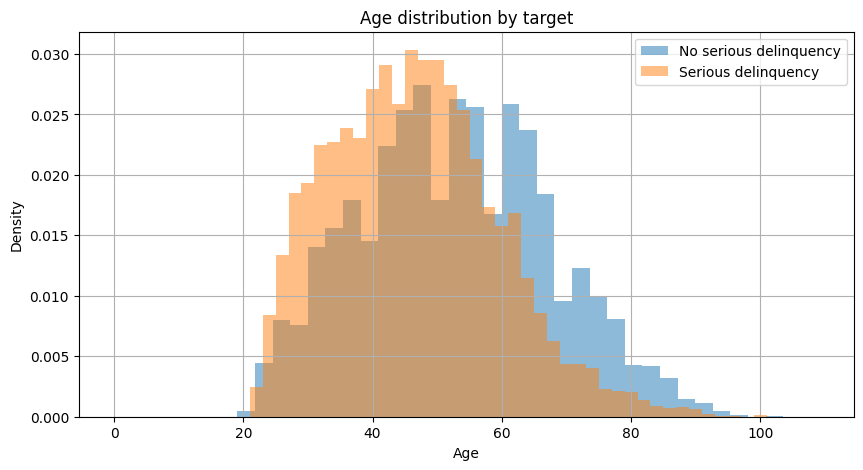

In [1310]:
plt.figure(figsize=(10, 5))

train.loc[
    train['SeriousDlqin2yrs'] == 0, 'age'
].hist(
    bins=40,
    alpha=0.5,
    density=True,
    label='No serious delinquency'
)

train.loc[
    train['SeriousDlqin2yrs'] == 1, 'age'
].hist(
    bins=40,
    alpha=0.5,
    density=True,
    label='Serious delinquency'
)

plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age distribution by target')
plt.legend()
plt.show()

In [1311]:
age_groups = pd.cut(
    train['age'],
    bins=[0, 30, 40, 50, 60, 70, 80, float('inf')],
    labels=['<=30', '31-40', '41-50', '51-60',
            '61-70', '71-80', '80+']
)

train.groupby(
    age_groups,
    observed=True
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
age,,
<=30,10757,0.115646
31-40,24339,0.098196
41-50,35037,0.082570
51-60,34806,0.061742
61-70,27424,0.034714
71-80,12700,0.023465
80+,4936,0.020259


age demonstrates a clear relationship with the target. The serious delinquency rate decreases consistently with age, from 11.6% among borrowers aged 30 or younger to 2.0% among borrowers aged 80+. Therefore, age appears to be an informative predictor of credit risk.

In [1312]:
util = train['RevolvingUtilizationOfUnsecuredLines']

util_groups = pd.cut(
    util,
    bins=[
        -float('inf'),
        0.2,
        0.4,
        0.6,
        0.8,
        1.0,
        float('inf')
    ],
    labels=[
        '<=0.2',
        '0.2-0.4',
        '0.4-0.6',
        '0.6-0.8',
        '0.8-1.0',
        '>1'
    ]
)

train.groupby(
    util_groups,
    observed=True
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
RevolvingUtilizationOfUnsecuredLines,,
<=0.2,81709,0.020157
0.2-0.4,19844,0.043892
0.4-0.6,13216,0.076044
0.6-0.8,10098,0.119331
0.8-1.0,21812,0.186182
>1,3321,0.372478


RevolvingUtilizationOfUnsecuredLines shows a strong monotonic relationship with the target. The serious delinquency rate increases from approximately 2.0% for utilization ≤0.2 to 37.2% for utilization >1. This suggests that credit utilization is a highly informative predictor of credit risk.

In [1313]:
temp = train.loc[
    train['NumberOfTimes90DaysLate'] < 96
]

temp.groupby(
    'NumberOfTimes90DaysLate'
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
).head(15)

,count,default_rate
NumberOfTimes90DaysLate,,
0,141662,0.046265
1,5243,0.336639
2,1555,0.499035
3,667,0.577211
4,291,0.670103
5,131,0.633588
6,80,0.600000
7,38,0.815789
8,21,0.714286


NumberOfTimes90DaysLate shows a strong relationship with the target. Borrowers with no 90+ day delinquencies have a serious delinquency rate of approximately 4.6%, compared with 33.7% for borrowers with one such delinquency and 49.9% for borrowers with two. Rates at very high counts are less stable because of the small number of observations.

In [1314]:
for col in delinq_cols:
    temp = train.loc[train[col] < 96]

    result = (
        temp.groupby(col)['SeriousDlqin2yrs']
        .agg(
            count='count',
            default_rate='mean'
        )
        .head(6)
    )

    print(f'\n--- {col} ---')
    print(result)


--- NumberOfTime30-59DaysPastDueNotWorse ---
                                       count  default_rate
NumberOfTime30-59DaysPastDueNotWorse                      
0                                     126018      0.040002
1                                      16033      0.150253
2                                       4598      0.265115
3                                       1754      0.352338
4                                        747      0.425703
5                                        342      0.450292

--- NumberOfTime60-89DaysPastDueNotWorse ---
                                       count  default_rate
NumberOfTime60-89DaysPastDueNotWorse                      
0                                     142396      0.050956
1                                       5731      0.310068
2                                       1118      0.501789
3                                        318      0.566038
4                                        105      0.619048
5                      

All three delinquency features show a strong positive relationship with the target. More frequent past-due events are associated with higher serious delinquency rates. The relationship is particularly strong for 60–89 day and 90+ day delinquencies.

In [1315]:
mask = train['MonthlyIncome'].notna() & (train['MonthlyIncome'] > 0)

debt_groups = pd.cut(
    train.loc[mask, 'DebtRatio'],
    bins=[-float('inf'), 0.2, 0.4, 0.6, 0.8, 1, float('inf')],
    labels=['<=0.2', '0.2-0.4', '0.4-0.6',
            '0.6-0.8', '0.8-1.0', '>1']
)

train.loc[mask].groupby(
    debt_groups,
    observed=True
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
DebtRatio,,
<=0.2,40570,0.060858
0.2-0.4,38284,0.056316
0.4-0.6,21522,0.076945
0.6-0.8,8824,0.101201
0.8-1.0,3723,0.118990
>1,5712,0.117997


DebtRatio: Among borrowers with known positive income, higher debt burden is generally associated with a higher serious delinquency rate. The default rate increases notably once DebtRatio exceeds approximately 0.4, reaching about 12% for ratios above 0.8.

In [1316]:
income_groups = pd.Series('positive_income', index=train.index)

income_groups[train['MonthlyIncome'].isna()] = 'missing_income'
income_groups[train['MonthlyIncome'] == 0] = 'zero_income'

train.groupby(
    income_groups
).agg(
    count=('SeriousDlqin2yrs', 'count'),
    default_rate=('SeriousDlqin2yrs', 'mean'),
    median_debt_ratio=('DebtRatio', 'median'),
    mean_debt_ratio=('DebtRatio', 'mean'),
    max_debt_ratio=('DebtRatio', 'max')
)

,count,default_rate,median_debt_ratio,mean_debt_ratio,max_debt_ratio
missing_income,29731,0.056137,1159.000000,1673.396556,329664.0
positive_income,118635,0.069887,0.292454,5.291856,61106.5
zero_income,1634,0.040392,930.000000,1573.567319,60212.0


DebtRatio and MonthlyIncome: Extremely large DebtRatio values are strongly associated with missing or zero MonthlyIncome. The median DebtRatio is only 0.29 for borrowers with positive reported income, compared with 1,159 for missing income and 930 for zero income. Therefore, these extreme values should not be treated as ordinary outliers without accounting for income availability.

In [1317]:
income_positive = train.loc[
    train['MonthlyIncome'].notna() &
    (train['MonthlyIncome'] > 0)
].copy()

income_positive['income_group'] = pd.qcut(
    income_positive['MonthlyIncome'],
    q=10,
    duplicates='drop'
)

income_positive.groupby(
    'income_group',
    observed=True
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean',
    median_income=lambda x: income_positive.loc[x.index, 'MonthlyIncome'].median()
)

,count,default_rate,median_income
income_group,,,
"(0.999, 2200.0]",12218,0.091832,1542.5
"(2200.0, 3041.0]",11513,0.097889,2664.0
"(3041.0, 3900.0]",12118,0.089041,3500.0
"(3900.0, 4600.0]",11720,0.081741,4200.0
"(4600.0, 5437.0]",11750,0.071745,5000.0
"(5437.0, 6400.0]",12033,0.066733,5964.0
"(6400.0, 7544.0]",11694,0.058748,7000.0
"(7544.0, 9166.0]",12114,0.050603,8328.0
"(9166.0, 11682.6]",11611,0.045216,10206.0


MonthlyIncome: Among borrowers with positive reported income, serious delinquency generally decreases as income increases. The default rate falls from approximately 9–10% in the lowest income groups to about 4.5% in the highest income groups, indicating a clear inverse relationship between income and credit risk.

## Data Preprocessing

Based on the EDA findings, the dataset contains several data quality issues that require preprocessing before model training:

- `age` contains an invalid value of 0.
- `MonthlyIncome` contains approximately 19.8% missing values and a small number of zero values.
- `NumberOfDependents` contains approximately 2.6% missing values.
- Delinquency features contain anomalous values 96 and 98.
- `RevolvingUtilizationOfUnsecuredLines` contains extreme values above the expected range.
- Extreme `DebtRatio` values are strongly related to missing or zero income and should not be treated as ordinary outliers.

In [1318]:
train_clean = train.copy()

print('Before:', train_clean.shape)

train_clean = train_clean[
    train_clean['age'] > 0
].copy()

print('After:', train_clean.shape)

Before: (150000, 11)
After: (149999, 11)


In [1319]:
train_clean['age'].min()

np.int64(21)

Age: One observation contained an invalid age of 0. Since this represents only one record out of 150,000 observations, the row was removed rather than imputed.

In [1320]:
income_median = train_clean.loc[
    train_clean['MonthlyIncome'] > 0,
    'MonthlyIncome'
].median()

income_median

np.float64(5436.5)

In [1321]:
train_clean['MonthlyIncome_missing'] = (
    train_clean['MonthlyIncome'].isna().astype(int)
)

train_clean['MonthlyIncome'] = (
    train_clean['MonthlyIncome'].fillna(income_median)
)

In [1322]:
print('Income median:', income_median)
print('Missing after:', train_clean['MonthlyIncome'].isna().sum())

print(
    train_clean['MonthlyIncome_missing'].value_counts()
)

Income median: 5436.5
Missing after: 0
MonthlyIncome_missing
0    120268
1     29731
Name: count, dtype: int64


MonthlyIncome: Approximately 19.8% of income values were missing. Missing values were imputed using the median of positive reported incomes (5,436.5). A separate MonthlyIncome_missing indicator was added to preserve information about the original missingness. Observed zero-income values were retained unchanged.

In [1323]:
dependents_median = train_clean[
    'NumberOfDependents'
].median()

dependents_median

np.float64(0.0)

In [1324]:
train_clean['NumberOfDependents_missing'] = (
    train_clean['NumberOfDependents'].isna().astype(int)
)

train_clean['NumberOfDependents'] = (
    train_clean['NumberOfDependents']
    .fillna(dependents_median)
)

In [1325]:
print('Median:', dependents_median)

print(
    'Missing after:',
    train_clean['NumberOfDependents'].isna().sum()
)

print(
    train_clean['NumberOfDependents_missing'].value_counts()
)

Median: 0.0
Missing after: 0
NumberOfDependents_missing
0    146075
1      3924
Name: count, dtype: int64


NumberOfDependents: Approximately 2.6% of values were missing. Missing values were imputed with the median (0), which is appropriate for this discrete and right-skewed feature. A separate NumberOfDependents_missing indicator was added to preserve information about the original missingness.

In [1326]:
delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in delinq_cols:
    normal_values = train_clean.loc[
        ~train_clean[col].isin([96, 98]),
        col
    ]

    print(
        col,
        'median =', normal_values.median()
    )

NumberOfTime30-59DaysPastDueNotWorse median = 0.0
NumberOfTime60-89DaysPastDueNotWorse median = 0.0
NumberOfTimes90DaysLate median = 0.0


In [1327]:
# indicator: row originally contained anomalous delinquency values
train_clean['delinquency_special'] = (
    train_clean[delinq_cols].isin([96, 98]).any(axis=1).astype(int)
)

# replace anomalous codes with median of normal values
for col in delinq_cols:
    normal_median = train_clean.loc[
        ~train_clean[col].isin([96, 98]),
        col
    ].median()

    train_clean.loc[
        train_clean[col].isin([96, 98]),
        col
    ] = normal_median

In [1328]:
print(
    train_clean['delinquency_special'].value_counts()
)

for col in delinq_cols:
    print(
        col,
        '96/98 remaining:',
        train_clean[col].isin([96, 98]).sum()
    )

delinquency_special
0    149730
1       269
Name: count, dtype: int64
NumberOfTime30-59DaysPastDueNotWorse 96/98 remaining: 0
NumberOfTime60-89DaysPastDueNotWorse 96/98 remaining: 0
NumberOfTimes90DaysLate 96/98 remaining: 0


In [1329]:
col = 'RevolvingUtilizationOfUnsecuredLines'

train_clean.loc[
    train_clean[col] > 1,
    col
].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count     3321.000000
mean       259.773362
std       1659.034074
min          1.000059
50%          1.074633
75%          1.301096
90%          2.197674
95%       1090.000000
99%       6723.000000
max      50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [1330]:
util_groups = pd.cut(
    train_clean[col],
    bins=[
        -float('inf'),
        1,
        2,
        5,
        10,
        100,
        1000,
        float('inf')
    ],
    labels=[
        '<=1',
        '1-2',
        '2-5',
        '5-10',
        '10-100',
        '100-1000',
        '>1000'
    ]
)

train_clean.groupby(
    util_groups,
    observed=True
)['SeriousDlqin2yrs'].agg(
    count='count',
    default_rate='mean'
)

,count,default_rate
RevolvingUtilizationOfUnsecuredLines,,
<=1,146678,0.059920
1-2,2950,0.401017
2-5,117,0.290598
5-10,13,0.230769
10-100,18,0.333333
100-1000,51,0.019608
>1000,172,0.058140


In [1331]:
col = 'RevolvingUtilizationOfUnsecuredLines'

# indicator for extreme utilization values
train_clean['utilization_extreme'] = (
    train_clean[col] > 10
).astype(int)

# cap extreme values
train_clean[col] = train_clean[col].clip(upper=10)

In [1332]:
print(
    train_clean['utilization_extreme'].value_counts()
)

print(
    train_clean[col].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

print('Max after clipping:', train_clean[col].max())

utilization_extreme
0    149758
1       241
Name: count, dtype: int64
count    149999.000000
mean          0.338302
std           0.533394
min           0.000000
50%           0.154176
75%           0.559044
90%           0.981256
95%           1.000000
99%           1.092958
max          10.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64
Max after clipping: 10.0


In [1333]:
train_clean['MonthlyIncome_zero'] = (
    train.loc[train_clean.index, 'MonthlyIncome'].eq(0)
).astype(int)

In [1334]:
train_clean.groupby(
    ['MonthlyIncome_missing', 'MonthlyIncome_zero']
)['DebtRatio'].agg(
    count='count',
    median='median',
    mean='mean',
    max='max'
)

count      median         mean  \
MonthlyIncome_missing MonthlyIncome_zero                                    
0                     0                   118634     0.29244     5.291897   
                      1                     1634   930.00000  1573.567319   
1                     0                    29731  1159.00000  1673.396556   

                                               max  
MonthlyIncome_missing MonthlyIncome_zero            
0                     0                    61106.5  
                      1                    60212.0  
1                     0                   329664.0

In [1335]:
valid_income_mask = (
    (train_clean['MonthlyIncome_missing'] == 0) &
    (train_clean['MonthlyIncome_zero'] == 0)
)

train_clean.loc[
    valid_income_mask,
    'DebtRatio'
].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
)

count    118634.000000
mean          5.291897
std         199.775067
min           0.000000
50%           0.292440
75%           0.473291
90%           0.724560
95%           0.982389
99%           2.994371
99.9%      1467.151500
max       61106.500000
Name: DebtRatio, dtype: float64

**DebtRatio:** Extremely large values were strongly associated with missing or zero income. Among borrowers with known positive income, the median DebtRatio was approximately 0.29 and 99% of observations were below 3, while a small number of extreme values remained. Since these values appear to reflect the feature's underlying definition rather than simple data errors, they were retained. Income-missing and zero-income indicators were preserved to help the model distinguish these cases.

In [1336]:
print('Shape:', train_clean.shape)

print('\nMissing values:')
print(train_clean.isna().sum())

print('\nDuplicates:', train_clean.duplicated().sum())

print('\nTarget distribution:')
print(
    train_clean['SeriousDlqin2yrs']
    .value_counts(normalize=True)
    .sort_index()
)

print('\nData types:')
print(train_clean.dtypes)

Shape: (149999, 16)

Missing values:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
NumberOfDependents_missing              0
delinquency_special                     0
utilization_extreme                     0
MonthlyIncome_zero                      0
dtype: int64

Duplicates: 609

Target distribution:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

Data types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
Number

In [1337]:
train_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,149999.0,0.338302,0.533394,0.0,0.029867,0.154176,0.559044,10.0
age,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,149999.0,0.245348,0.697231,0.0,0.000000,0.000000,0.000000,13.0
DebtRatio,149999.0,353.007426,2037.825113,0.0,0.175074,0.366503,0.868257,329664.0
MonthlyIncome,149999.0,6425.692301,12889.875066,0.0,3903.000000,5436.500000,7400.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,149999.0,0.090294,0.485108,0.0,0.000000,0.000000,0.000000,17.0
NumberRealEstateLoansOrLines,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,149999.0,0.064707,0.329790,0.0,0.000000,0.000000,0.000000,11.0


### Data Cleaning Summary

After exploratory data analysis, the following preprocessing steps were applied:

- One observation with an invalid age of 0 was removed.
- Missing `MonthlyIncome` values were imputed with the median, while a separate missing-value indicator was retained.
- Missing `NumberOfDependents` values were imputed with the median (0), with an additional missing-value indicator.
- Anomalous delinquency values 96 and 98 were replaced with the median of valid values (0), while `delinquency_special` preserves information about these observations.
- Extreme `RevolvingUtilizationOfUnsecuredLines` values were capped at 10, with an additional `utilization_extreme` indicator.
- Extreme `DebtRatio` values were retained because they are strongly associated with missing or zero income and appear to reflect the feature definition rather than simple data errors.
- A `MonthlyIncome_zero` indicator was added to distinguish borrowers with reported zero income.

The final cleaned dataset contains 149,999 observations and 16 columns with no missing values.

The target remains highly imbalanced: approximately 6.68% of borrowers experienced serious delinquency.

In [1338]:
X = train_clean.drop(columns='SeriousDlqin2yrs')
y = train_clean['SeriousDlqin2yrs']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (149999, 15)
y shape: (149999,)


In [1339]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

print('\nTrain target:')
print(y_train.value_counts(normalize=True))

print('\nTest target:')
print(y_test.value_counts(normalize=True))

X_train: (119999, 15)
X_test: (30000, 15)

Train target:
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64

Test target:
SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


In [1340]:
dummy = DummyClassifier(
    strategy='prior',
    random_state=42
)

dummy.fit(X_train, y_train)

dummy_proba = dummy.predict_proba(X_test)[:, 1]

print(
    'ROC-AUC:',
    roc_auc_score(y_test, dummy_proba)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, dummy_proba)
)

ROC-AUC: 0.5
PR-AUC: 0.06683333333333333


In [1341]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'delinquency_special', 'utilization_extreme','MonthlyIncome_zero']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [1342]:
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

In [1343]:
print(classification_report(y_test, logreg_pred))

print('Confusion matrix:')
print(confusion_matrix(y_test, logreg_pred))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, logreg_proba)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, logreg_proba)
)

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000

Confusion matrix:
[[27743   252]
 [ 1654   351]]
ROC-AUC: 0.8580960885872477
PR-AUC: 0.3814745236514353


In [1344]:
logreg_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

logreg_balanced.fit(X_train, y_train)

balanced_pred = logreg_balanced.predict(X_test)
balanced_proba = logreg_balanced.predict_proba(X_test)[:, 1]

In [1345]:
print(classification_report(y_test, balanced_pred))

print('Confusion matrix:')
print(confusion_matrix(y_test, balanced_pred))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, balanced_proba)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, balanced_proba)
)

              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.75      0.35      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.62     30000
weighted avg       0.93      0.81      0.85     30000

Confusion matrix:
[[22804  5191]
 [  503  1502]]
ROC-AUC: 0.8612441391609386
PR-AUC: 0.38481574069204155


In [1346]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

results = []

for threshold in thresholds:
    pred = (logreg_proba >= threshold).astype(int)

    results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.05,0.176061,0.831920,0.290618
1,0.10,0.282762,0.641397,0.392492
2,0.15,0.404888,0.495761,0.445740
3,0.20,0.450476,0.401496,0.424578
4,0.25,0.487805,0.339152,0.400118
5,0.30,0.511054,0.299751,0.377869
6,0.40,0.550239,0.229426,0.323830
7,0.50,0.582090,0.175062,0.269172


In [1347]:
threshold_results.loc[
    threshold_results['f1'].idxmax()
]

threshold    0.150000
precision    0.404888
recall       0.495761
f1           0.445740
Name: 2, dtype: float64

### Threshold analysis

The default classification threshold of 0.5 produced high precision but very low recall for the minority class.

Lowering the threshold substantially improved the detection of serious delinquency cases. Among the tested thresholds, 0.15 achieved the highest F1-score:

- Precision: 0.405
- Recall: 0.496
- F1-score: 0.446

This demonstrates the precision-recall trade-off. In a credit-risk setting, the optimal threshold should ultimately be selected based on the relative business costs of false negatives and false positives rather than F1-score alone.

The threshold analysis shown here is exploratory; final threshold selection should be performed using validation data rather than the held-out test set.

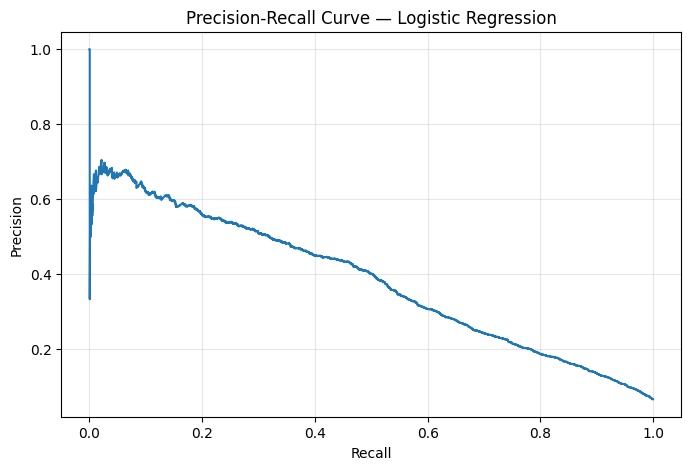

In [1348]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    logreg_proba
)

plt.figure(figsize=(8, 5))

plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Logistic Regression')

plt.grid(alpha=0.3)
plt.show()

In [1349]:
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

print('Best threshold:', thresholds[best_idx])
print('Precision:', precision[best_idx])
print('Recall:', recall[best_idx])
print('F1:', f1_scores[best_idx])

Best threshold: 0.15117972597917645
Precision: 0.407986825854261
Recall: 0.4942643391521197
F1: 0.4470004510104482


### Precision–Recall Analysis

The Precision–Recall curve illustrates the trade-off between identifying more high-risk borrowers and maintaining precision.

Searching across all available probability thresholds showed that the maximum F1-score is achieved at a threshold of approximately **0.15**:

- Precision: **0.408**
- Recall: **0.494**
- F1-score: **0.447**

This is consistent with the earlier manual threshold analysis.

Compared with the default threshold of 0.5, lowering the threshold substantially improves the detection of serious delinquency cases, at the cost of more false-positive predictions.

For simplicity and interpretability, a threshold of **0.15** is used as the candidate operating threshold.

In a real credit-risk application, the final threshold should be selected based on the business costs of false positives and false negatives rather than F1-score alone.

In [1350]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))

print('Confusion matrix:')
print(confusion_matrix(y_test, rf_pred))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, rf_proba)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, rf_proba)
)

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.55      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000

Confusion matrix:
[[27697   298]
 [ 1640   365]]
ROC-AUC: 0.8495318232370493
PR-AUC: 0.3662614756989317


In [1351]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)
rf_balanced_proba = rf_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_balanced_pred))

print('Confusion matrix:')
print(confusion_matrix(y_test, rf_balanced_pred))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, rf_balanced_proba)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, rf_balanced_proba)
)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     27995
           1       0.43      0.36      0.39      2005

    accuracy                           0.93     30000
   macro avg       0.69      0.66      0.68     30000
weighted avg       0.92      0.93      0.92     30000

Confusion matrix:
[[27042   953]
 [ 1284   721]]
ROC-AUC: 0.8489111388344643
PR-AUC: 0.3448792120013471


In [1352]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hgb.fit(X_train, y_train)

hgb_pred = hgb.predict(X_test)
hgb_proba = hgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, hgb_pred))

print('Confusion matrix:')
print(confusion_matrix(y_test, hgb_pred))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, hgb_proba)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, hgb_proba)
)

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.59      0.20      0.29      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000

Confusion matrix:
[[27726   269]
 [ 1614   391]]
ROC-AUC: 0.8691335244670962
PR-AUC: 0.40357477773619305


In [1353]:
thresholds_to_test = [
    0.05, 0.10, 0.15, 0.20,
    0.25, 0.30, 0.40, 0.50
]

results = []

for threshold in thresholds_to_test:
    pred = (hgb_proba >= threshold).astype(int)

    results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred)
    })

hgb_threshold_results = pd.DataFrame(results)

hgb_threshold_results

,threshold,precision,recall,f1
0,0.05,0.186756,0.836908,0.305369
1,0.10,0.272168,0.684289,0.389441
2,0.15,0.346388,0.595511,0.438004
3,0.20,0.395385,0.512718,0.446471
4,0.25,0.436407,0.460349,0.448058
5,0.30,0.470136,0.396509,0.430195
6,0.40,0.541935,0.293267,0.380583
7,0.50,0.592424,0.195012,0.293433


In [1354]:
hgb_threshold_results.loc[
    hgb_threshold_results['f1'].idxmax()
]

threshold    0.250000
precision    0.436407
recall       0.460349
f1           0.448058
Name: 4, dtype: float64

In [1355]:
precision_hgb, recall_hgb, thresholds_hgb = precision_recall_curve(
    y_test,
    hgb_proba
)

f1_hgb = (
    2 * precision_hgb[:-1] * recall_hgb[:-1]
    / (precision_hgb[:-1] + recall_hgb[:-1] + 1e-10)
)

best_idx_hgb = np.argmax(f1_hgb)

print('Best threshold:', thresholds_hgb[best_idx_hgb])
print('Precision:', precision_hgb[best_idx_hgb])
print('Recall:', recall_hgb[best_idx_hgb])
print('F1:', f1_hgb[best_idx_hgb])

Best threshold: 0.24623854829448297
Precision: 0.4356943150046598
Recall: 0.46633416458852867
F1: 0.450493856852009


In [1356]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print('Train:', X_train_final.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

print('\nTrain target:')
print(y_train_final.value_counts(normalize=True))

print('\nValidation target:')
print(y_val.value_counts(normalize=True))

Train: (95999, 15)
Validation: (24000, 15)
Test: (30000, 15)

Train target:
SeriousDlqin2yrs
0    0.933156
1    0.066844
Name: proportion, dtype: float64

Validation target:
SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


In [1357]:
hgb_final = HistGradientBoostingClassifier(
    random_state=42
)

hgb_final.fit(X_train_final, y_train_final)

val_proba = hgb_final.predict_proba(X_val)[:, 1]

In [1358]:
precision_val, recall_val, thresholds_val = precision_recall_curve(
    y_val,
    val_proba
)

f1_val = (
    2 * precision_val[:-1] * recall_val[:-1]
    / (precision_val[:-1] + recall_val[:-1] + 1e-10)
)

best_idx_val = np.argmax(f1_val)

best_threshold = thresholds_val[best_idx_val]

print('Best validation threshold:', best_threshold)
print('Precision:', precision_val[best_idx_val])
print('Recall:', recall_val[best_idx_val])
print('F1:', f1_val[best_idx_val])

Best validation threshold: 0.19938530711700025
Precision: 0.4062205466540999
Recall: 0.5374064837905237
F1: 0.462694578587574


In [1359]:
# probabilities on untouched test set
test_proba = hgb_final.predict_proba(X_test)[:, 1]

# use threshold selected ONLY on validation
test_pred = (test_proba >= best_threshold).astype(int)

print('Final threshold:', best_threshold)

print('\nClassification report:')
print(classification_report(y_test, test_pred))

print('Confusion matrix:')
print(confusion_matrix(y_test, test_pred))

print(
    '\nROC-AUC:',
    roc_auc_score(y_test, test_proba)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, test_proba)
)

Final threshold: 0.19938530711700025

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27995
           1       0.39      0.52      0.45      2005

    accuracy                           0.91     30000
   macro avg       0.68      0.73      0.70     30000
weighted avg       0.93      0.91      0.92     30000

Confusion matrix:
[[26398  1597]
 [  970  1035]]

ROC-AUC: 0.8675655832734649
PR-AUC: 0.4027848034789416


### Final HistGradientBoosting Model

The final HistGradientBoosting model was evaluated on an untouched test set using a decision threshold selected exclusively on the validation set.

- Validation-selected threshold: **0.199**
- Test ROC-AUC: **0.868**
- Test PR-AUC: **0.403**
- Precision (default class): **0.39**
- Recall (default class): **0.52**
- F1-score (default class): **0.45**

The lower decision threshold improved the detection of borrowers at risk of serious delinquency compared with the default 0.5 threshold. Approximately 52% of actual positive cases were identified.

Because the dataset is highly imbalanced, ROC-AUC, PR-AUC, precision, recall, and F1-score were prioritized over accuracy.

In [1360]:
perm_importance = permutation_importance(
    hgb_final,
    X_val,
    y_val,
    scoring='average_precision',
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values(
    'importance',
    ascending=False
)

importance_df

,feature,importance,std
6,NumberOfTimes90DaysLate,0.109318,0.005504
0,RevolvingUtilizationOfUnsecuredLines,0.079041,0.003976
2,NumberOfTime30-59DaysPastDueNotWorse,0.035465,0.002869
8,NumberOfTime60-89DaysPastDueNotWorse,0.034256,0.001923
5,NumberOfOpenCreditLinesAndLoans,0.015897,0.002907
1,age,0.013067,0.001970
3,DebtRatio,0.010855,0.002371
7,NumberRealEstateLoansOrLines,0.007123,0.001421
12,delinquency_special,0.007029,0.000400
4,MonthlyIncome,0.004445,0.001046


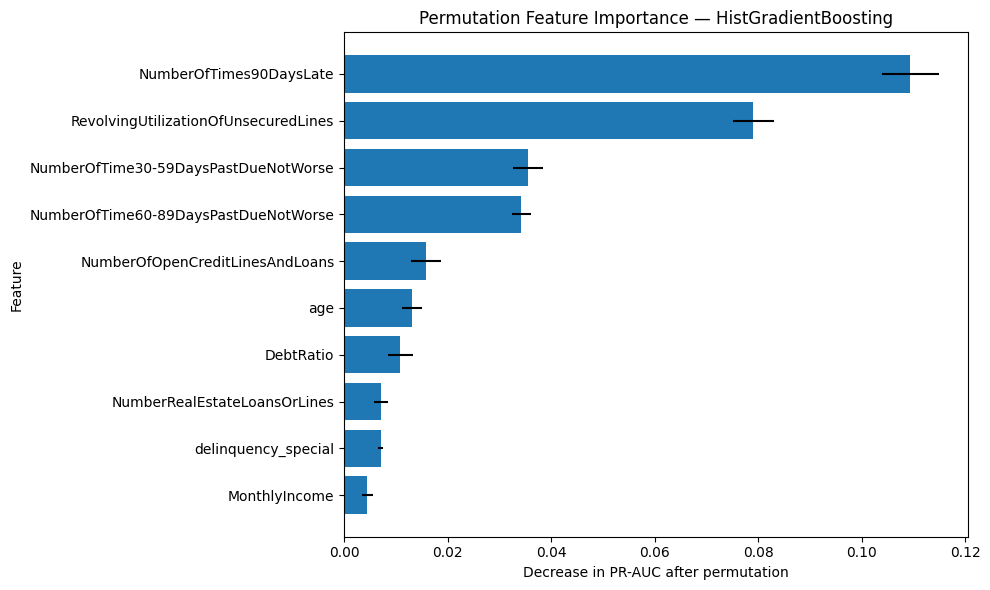

In [1361]:
top_importance = importance_df.head(10).sort_values(
    'importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importance['feature'],
    top_importance['importance'],
    xerr=top_importance['std']
)

plt.xlabel('Decrease in PR-AUC after permutation')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance — HistGradientBoosting')

plt.tight_layout()
plt.show()

### Feature Importance

Permutation importance was calculated on the validation set using PR-AUC as the scoring metric.

The strongest predictors were related to previous delinquency behavior. `NumberOfTimes90DaysLate` had the highest importance, followed by `RevolvingUtilizationOfUnsecuredLines` and the number of 30–59 and 60–89 day past-due events.

This suggests that historical repayment behavior and revolving credit utilization contain substantially more predictive information for serious delinquency than demographic or missing-value indicators.

Permutation importance measures the decrease in model performance when a feature is randomly shuffled. Therefore, it reflects predictive importance rather than the direction or causal effect of a feature.

In [1362]:
X_val_pdp = X_val.copy()

X_val_pdp = X_val_pdp.astype(float)

X_val_pdp.dtypes

RevolvingUtilizationOfUnsecuredLines    float64
age                                     float64
NumberOfTime30-59DaysPastDueNotWorse    float64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans         float64
NumberOfTimes90DaysLate                 float64
NumberRealEstateLoansOrLines            float64
NumberOfTime60-89DaysPastDueNotWorse    float64
NumberOfDependents                      float64
MonthlyIncome_missing                   float64
NumberOfDependents_missing              float64
delinquency_special                     float64
utilization_extreme                     float64
MonthlyIncome_zero                      float64
dtype: object

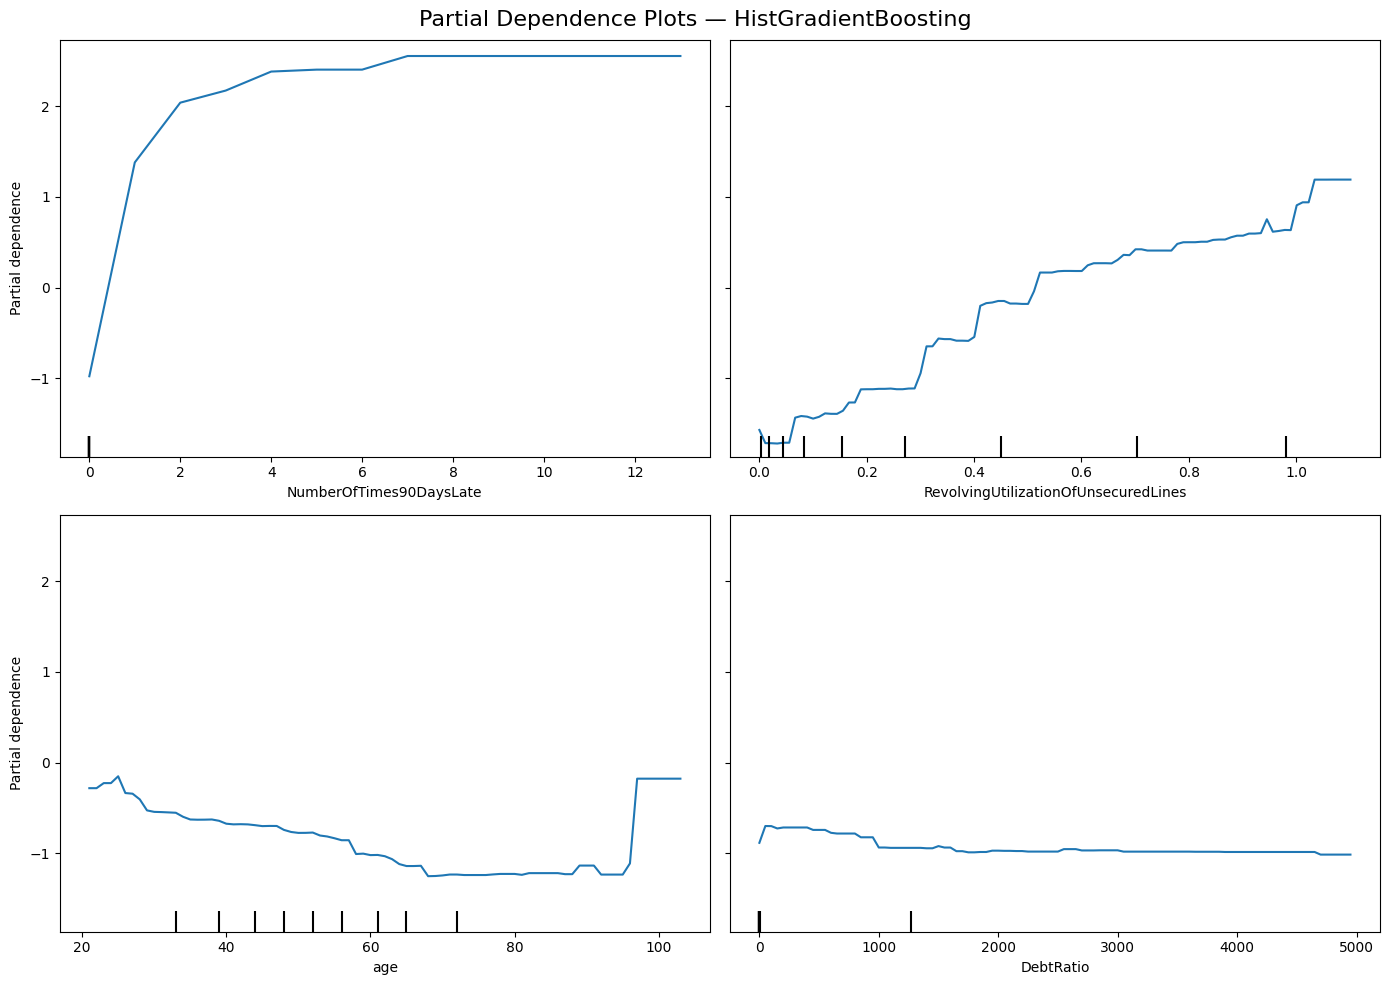

In [1363]:
X_val_pdp = X_val.copy().astype(float)

features_to_plot = [
    'NumberOfTimes90DaysLate',
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio'
]

fig, ax = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

PartialDependenceDisplay.from_estimator(
    hgb_final,
    X_val_pdp, 
    features=features_to_plot,
    ax=ax,
    kind='average',
    percentiles=(0.01, 0.99)
)

plt.suptitle(
    'Partial Dependence Plots — HistGradientBoosting',
    fontsize=16
)

plt.tight_layout()
plt.show()

### Partial Dependence Analysis

Partial dependence analysis reveals several nonlinear relationships learned by the model:

- **90+ days past due:** The strongest increase in model output occurs between zero and the first few serious delinquency events, after which the effect gradually plateaus.
- **Revolving utilization:** Higher utilization of unsecured credit is associated with progressively higher predicted risk.
- **Age:** The model generally associates higher age with lower predicted risk, although behavior at extreme ages should be interpreted cautiously due to lower data density.
- **Debt ratio:** The partial dependence is comparatively flat, suggesting a weaker marginal effect than delinquency history and revolving utilization.

These relationships describe the behavior learned by the model and should not be interpreted as causal effects.

In [1364]:
test_pred = (test_proba >= best_threshold).astype(int)

error_analysis = X_test.copy()

error_analysis['actual'] = y_test.values
error_analysis['predicted'] = test_pred
error_analysis['probability'] = test_proba

error_analysis['error_type'] = 'Correct'

error_analysis.loc[
    (error_analysis['actual'] == 0) &
    (error_analysis['predicted'] == 1),
    'error_type'
] = 'False Positive'

error_analysis.loc[
    (error_analysis['actual'] == 1) &
    (error_analysis['predicted'] == 0),
    'error_type'
] = 'False Negative'

error_analysis['error_type'].value_counts()

error_type
Correct           27433
False Positive     1597
False Negative      970
Name: count, dtype: int64

In [1365]:
features_for_analysis = [
    'NumberOfTimes90DaysLate',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines'
]

error_summary = (
    error_analysis
    .groupby('error_type')[features_for_analysis]
    .median()
    .T
)

error_summary

error_type,Correct,False Negative,False Positive
NumberOfTimes90DaysLate,0.000000,0.000000,0.000000
RevolvingUtilizationOfUnsecuredLines,0.129976,0.512933,0.942673
NumberOfTime30-59DaysPastDueNotWorse,0.000000,0.000000,1.000000
NumberOfTime60-89DaysPastDueNotWorse,0.000000,0.000000,0.000000
age,53.000000,46.000000,45.000000
DebtRatio,0.361047,0.429181,0.412903
MonthlyIncome,5436.500000,5436.500000,5200.000000
NumberOfOpenCreditLinesAndLoans,8.000000,8.500000,6.000000
NumberRealEstateLoansOrLines,1.000000,1.000000,0.000000


In [1366]:
false_positives = (
    error_analysis[
        error_analysis['error_type'] == 'False Positive'
    ]
    .sort_values('probability', ascending=False)
)

false_negatives = (
    error_analysis[
        error_analysis['error_type'] == 'False Negative'
    ]
    .sort_values('probability', ascending=True)
)

print('Most confident False Positives:')
display(false_positives.head(10))

print('\nMost confident False Negatives:')
display(false_negatives.head(10))

Most confident False Positives:


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing,delinquency_special,utilization_extreme,MonthlyIncome_zero,actual,predicted,probability,error_type
111673,1.118752,38,3,0.411931,6000.0,9,1,1,4,2.0,0,0,0,0,0,0,1,0.793092,False Positive
81260,0.987789,45,4,0.176627,4500.0,5,3,0,2,4.0,0,0,0,0,0,0,1,0.768878,False Positive
26572,1.043410,38,4,0.465365,4200.0,9,1,0,3,3.0,0,0,0,0,0,0,1,0.763080,False Positive
111927,1.466551,42,4,0.366162,2375.0,6,5,0,0,3.0,0,0,0,0,0,0,1,0.756589,False Positive
31052,1.033527,47,4,0.874736,3783.0,10,0,1,2,3.0,0,0,0,0,0,0,1,0.752730,False Positive
129131,0.996495,62,4,4437.000000,5436.5,18,3,0,4,0.0,1,0,0,0,0,0,1,0.748494,False Positive
5156,0.948293,42,4,0.502767,5600.0,7,3,1,2,2.0,0,0,0,0,0,0,1,0.747053,False Positive
146044,0.687749,45,2,0.787285,2500.0,24,6,1,4,2.0,0,0,0,0,0,0,1,0.743092,False Positive
20726,0.951173,30,0,2.707934,4700.0,7,10,0,1,0.0,0,0,0,0,0,0,1,0.742633,False Positive
141567,0.599408,63,8,0.427368,7000.0,13,6,2,3,0.0,0,0,0,0,0,0,1,0.728859,False Positive



Most confident False Negatives:


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing,delinquency_special,utilization_extreme,MonthlyIncome_zero,actual,predicted,probability,error_type
32516,0.003526,75,0,769.000000,5436.5,8,0,1,0,0.0,1,0,0,0,0,1,0,0.005143,False Negative
4423,0.003952,87,0,269.000000,5436.5,7,0,1,0,0.0,1,1,0,0,0,1,0,0.005222,False Negative
27264,0.024450,67,0,705.000000,5436.5,8,0,1,0,0.0,1,0,0,0,0,1,0,0.005508,False Negative
49887,0.107586,67,0,3233.000000,0.0,7,0,1,0,0.0,0,0,0,0,1,1,0,0.005509,False Negative
24827,0.000000,81,0,636.000000,5436.5,10,0,1,0,0.0,1,0,0,0,0,1,0,0.005846,False Negative
8825,0.048674,64,0,2446.000000,5436.5,4,0,2,0,0.0,1,0,0,0,0,1,0,0.005982,False Negative
40010,0.102562,73,0,2337.000000,5436.5,9,0,1,0,2.0,1,0,0,0,0,1,0,0.005987,False Negative
112688,0.054184,87,0,0.010998,5000.0,7,0,0,0,1.0,0,0,0,0,0,1,0,0.006142,False Negative
82006,0.000000,58,0,0.000000,11000.0,7,0,0,0,0.0,0,0,0,0,0,1,0,0.006203,False Negative
112629,0.022835,65,0,155.000000,5436.5,8,0,0,0,0.0,1,0,0,0,0,1,0,0.006374,False Negative


In [1367]:
error_analysis['prediction_group'] = np.select(
    [
        (error_analysis['actual'] == 0) & (error_analysis['predicted'] == 0),
        (error_analysis['actual'] == 0) & (error_analysis['predicted'] == 1),
        (error_analysis['actual'] == 1) & (error_analysis['predicted'] == 0),
        (error_analysis['actual'] == 1) & (error_analysis['predicted'] == 1)
    ],
    [
        'True Negative',
        'False Positive',
        'False Negative',
        'True Positive'
    ],
    default='Unknown'
)

error_analysis['prediction_group'].value_counts()

prediction_group
True Negative     26398
False Positive     1597
True Positive      1035
False Negative      970
Name: count, dtype: int64

In [1368]:
group_summary = (
    error_analysis
    .groupby('prediction_group')[features_for_analysis]
    .median()
    .T
)

group_summary

prediction_group,False Negative,False Positive,True Negative,True Positive
NumberOfTimes90DaysLate,0.000000,0.000000,0.00000,1.000000
RevolvingUtilizationOfUnsecuredLines,0.512933,0.942673,0.11819,0.997000
NumberOfTime30-59DaysPastDueNotWorse,0.000000,1.000000,0.00000,1.000000
NumberOfTime60-89DaysPastDueNotWorse,0.000000,0.000000,0.00000,0.000000
age,46.000000,45.000000,53.00000,43.000000
DebtRatio,0.429181,0.412903,0.35819,0.445299
MonthlyIncome,5436.500000,5200.000000,5436.50000,5000.000000
NumberOfOpenCreditLinesAndLoans,8.500000,6.000000,8.00000,6.000000
NumberRealEstateLoansOrLines,1.000000,0.000000,1.00000,0.000000


In [1369]:
error_analysis['prediction_group'] = np.select(
    [
        (error_analysis['actual'] == 0) & (error_analysis['predicted'] == 0),
        (error_analysis['actual'] == 0) & (error_analysis['predicted'] == 1),
        (error_analysis['actual'] == 1) & (error_analysis['predicted'] == 0),
        (error_analysis['actual'] == 1) & (error_analysis['predicted'] == 1)
    ],
    [
        'True Negative',
        'False Positive',
        'False Negative',
        'True Positive'
    ],
    default='Unknown'
)

error_analysis['prediction_group'].value_counts()

prediction_group
True Negative     26398
False Positive     1597
True Positive      1035
False Negative      970
Name: count, dtype: int64

In [1370]:
probability_summary = (
    error_analysis
    .groupby('prediction_group')['probability']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(3)
)

probability_summary

,count,mean,median,min,max
prediction_group,,,,,
False Negative,970,0.085,0.079,0.005,0.199
False Positive,1597,0.356,0.317,0.199,0.793
True Negative,26398,0.035,0.017,0.004,0.199
True Positive,1035,0.441,0.431,0.200,0.822


In [1371]:
model_comparison = pd.DataFrame({
    'Model': [
        'Dummy',
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest',
        'Balanced Random Forest',
        'HistGradientBoosting',
        'Final HGB + tuned threshold'
    ],

    'ROC-AUC': [
        0.500,
        0.858,
        0.861,
        0.850,
        0.849,
        0.869,
        0.868
    ],

    'PR-AUC': [
        0.067,
        0.381,
        0.385,
        0.366,
        0.345,
        0.404,
        0.403
    ]
})

model_comparison.round(3)

,Model,ROC-AUC,PR-AUC
0,Dummy,0.500,0.067
1,Logistic Regression,0.858,0.381
2,Balanced Logistic Regression,0.861,0.385
3,Random Forest,0.850,0.366
4,Balanced Random Forest,0.849,0.345
5,HistGradientBoosting,0.869,0.404
6,Final HGB + tuned threshold,0.868,0.403


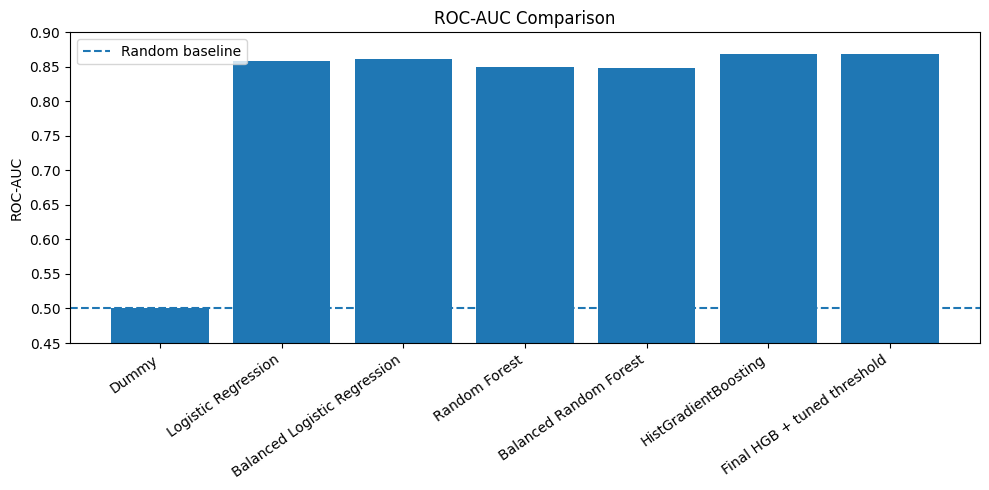

In [1372]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['ROC-AUC']
)

plt.axhline(
    0.5,
    linestyle='--',
    label='Random baseline'
)

plt.ylabel('ROC-AUC')
plt.title('ROC-AUC Comparison')

plt.xticks(rotation=35, ha='right')

plt.ylim(0.45, 0.90)

plt.legend()
plt.tight_layout()
plt.show()

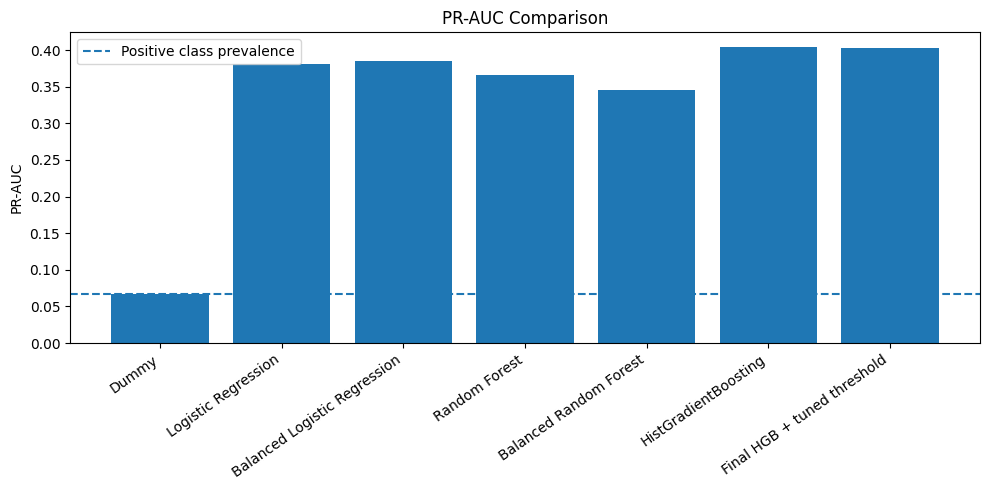

In [1373]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['PR-AUC']
)

plt.axhline(
    y_train_final.mean(),
    linestyle='--',
    label='Positive class prevalence'
)

plt.ylabel('PR-AUC')
plt.title('PR-AUC Comparison')

plt.xticks(rotation=35, ha='right')

plt.legend()
plt.tight_layout()
plt.show()

In [1374]:
final_metrics = pd.DataFrame({
    'Metric': [
        'Threshold',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC',
        'PR-AUC'
    ],
    
    'Value': [
        best_threshold,
        0.39,
        0.52,
        0.45,
        0.868,
        0.403
    ]
})

final_metrics

,Metric,Value
0,Threshold,0.199385
1,Precision,0.390000
2,Recall,0.520000
3,F1-score,0.450000
4,ROC-AUC,0.868000
5,PR-AUC,0.403000


## Final Conclusions

The goal of this project was to predict the probability of serious financial delinquency using an imbalanced credit-risk dataset.

### Model performance

Several classification approaches were evaluated, including:

- Dummy Classifier
- Logistic Regression
- Logistic Regression with class weighting
- Random Forest
- Random Forest with class weighting
- HistGradientBoosting

Because only about 6.7% of observations belong to the positive class, accuracy alone is not an appropriate evaluation metric. Therefore, ROC-AUC, PR-AUC, precision, recall and F1-score were used to evaluate model performance.

HistGradientBoosting achieved the strongest probability-ranking performance, with approximately:

- ROC-AUC: 0.868
- PR-AUC: 0.403

compared with a PR-AUC baseline of approximately 0.067.

### Threshold optimization

The default classification threshold of 0.5 resulted in low recall for the minority class.

Instead of selecting the threshold using the test set, a separate validation set was created. The threshold that maximized the F1-score on validation data was approximately 0.199.

This threshold was then applied once to the untouched test set.

Final test performance for the positive class:

- Precision: 0.39
- Recall: 0.52
- F1-score: 0.45

The model correctly identified 1,035 of 2,005 positive cases.

### Model interpretation

Permutation importance showed that the most influential features included:

1. NumberOfTimes90DaysLate
2. RevolvingUtilizationOfUnsecuredLines
3. NumberOfTime30-59DaysPastDueNotWorse
4. NumberOfTime60-89DaysPastDueNotWorse

Partial dependence analysis also showed that predicted risk generally increases with the number of serious late payments and with revolving credit utilization.

### Error analysis

False positives were characterized by relatively high revolving credit utilization and more frequent 30–59 day delinquencies. These observations therefore resemble high-risk customers even though their actual target is negative.

False negatives were more difficult to detect. Their median revolving utilization was higher than that of true negatives, but they generally lacked strong delinquency signals.

The predicted probabilities also followed a meaningful ordering:

True Negative < False Negative < False Positive < True Positive.

This indicates that the model provides useful risk ranking even for some observations that are misclassified by the selected decision threshold.

### Final result

The final model is a HistGradientBoosting classifier with a decision threshold selected on validation data.

The project demonstrates the importance of handling class imbalance, selecting appropriate evaluation metrics, separating threshold tuning from final test evaluation, and performing model interpretation and error analysis rather than relying only on accuracy.

In [1375]:
X_deploy = pd.concat(
    [X_train_final, X_val],
    axis=0
)

y_deploy = pd.concat(
    [y_train_final, y_val],
    axis=0
)

print('X_deploy:', X_deploy.shape)
print('y_deploy:', y_deploy.shape)
print('\nTarget distribution:')
print(y_deploy.value_counts(normalize=True))

X_deploy: (119999, 15)
y_deploy: (119999,)

Target distribution:
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


In [1376]:
final_model = HistGradientBoostingClassifier(
    random_state=42
)

final_model.fit(
    X_deploy,
    y_deploy
)

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [1377]:
FINAL_THRESHOLD = best_threshold

print('Deployment threshold:', FINAL_THRESHOLD)

Deployment threshold: 0.19938530711700025


In [1378]:
feature_names = X_deploy.columns.tolist()

feature_names

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'MonthlyIncome_missing',
 'NumberOfDependents_missing',
 'delinquency_special',
 'utilization_extreme',
 'MonthlyIncome_zero']

In [1379]:
len(feature_names)

15

In [1380]:
import joblib

In [1381]:
model_artifact = {
    'model': final_model,
    'threshold': FINAL_THRESHOLD,
    'features': feature_names
}

joblib.dump(
    model_artifact,
    '../models/credit_risk_model.joblib'
)

['../models/credit_risk_model.joblib']

In [1383]:
loaded_artifact = joblib.load(
    '../models/credit_risk_model.joblib'
)

loaded_artifact.keys()

dict_keys(['model', 'threshold', 'features'])

In [1384]:
loaded_model = loaded_artifact['model']
loaded_threshold = loaded_artifact['threshold']
loaded_features = loaded_artifact['features']

sample = X_test.iloc[[0]][loaded_features]

sample_probability = loaded_model.predict_proba(sample)[0, 1]

sample_prediction = int(
    sample_probability >= loaded_threshold
)

print('Probability:', sample_probability)
print('Threshold:', loaded_threshold)
print('Prediction:', sample_prediction)
print('Actual:', y_test.iloc[0])

Probability: 0.012961569145624902
Threshold: 0.19938530711700025
Prediction: 0
Actual: 0


True
